In [ ]:
import matplotlib.pyplot as plt
import PcmPy as pcm
import globals as gl
import numpy as np
from Pcm import make_planning_models, make_execution_models, find_model

plt.style.use('default')

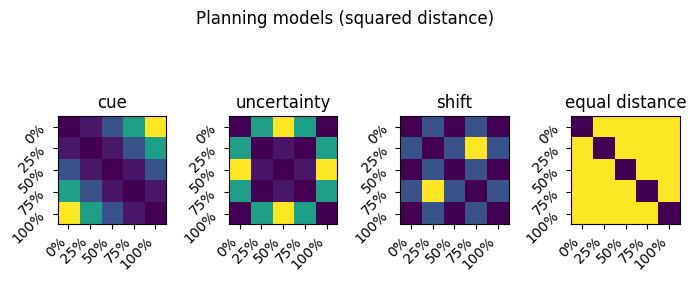

In [4]:
experiment = 'smp2'

M = make_planning_models(experiment)

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'planning force'):
        D.append(pcm.G_to_dist(m.G))
        G.append(m.G)
        name.append(m.name)
    # if isinstance(m, pcm.ComponentModel):
    #     D.append(pcm.G_to_dist(m.Gc.sum(axis=0)))
    #     name.append(m.name)

fig, axs = plt.subplots(1, len(D), figsize=(7, 3), )

for i, (g, d, n) in enumerate(zip(G, D, name)):
    # d = np.sign(d) * np.sqrt(np.abs(d))
    axs[i].imshow(d, )
    mds, _ = pcm.classical_mds(g)

    # sizes = np.array([40, 60, 80, 100, 120])
    # axs[1, i].scatter(mds[:, 0], mds[:, 1], color=list(gl.colour_mapping.values())[:5][::-1], s=sizes[::-1], alpha=.3, edgecolors='none')
    axs[i].set_title(n)

    axs[i].set_xticks(np.arange(5))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')
    axs[i].set_yticks(np.arange(5))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[:5], rotation=45, ha='right')

    # axs[1, i].set_xticks([])
    # axs[1, i].set_yticks([])
    # lims = np.array([mds.min(), mds.max()])
    # axs[1, i].set_xlim(lims + .1 * lims)
    # axs[1, i].set_ylim(lims)
    # axs[1, i].set_aspect('equal', adjustable='box')

fig.suptitle('Planning models (squared distance)')
fig.tight_layout()

plt.show()



In [5]:
experiment = 'smp2'

M = make_planning_models(experiment, test_planning_force=True)

vmin, vmax=-4, 4

D, G, name = [], [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & ((m.name == 'cue') | (m.name == 'uncertainty')):
        D.append(pcm.G_to_dist(m.G))
        G.append(m.G)
        name.append(m.name)

mds = []

for i, g in enumerate(G):
    mds_tmp, _ = pcm.classical_mds(g)
    mds.append(mds_tmp[:, 0])

mds = np.array(mds)

fig, axs = plt.subplots(figsize=(2, 2))
axs.scatter(mds[0], mds[1] * -1, color='k', lw=.8)
axs.set_xticks(mds[0])
axs.set_yticks(np.unique(np.round(mds[1] * -1, decimals=3)))
axs.set_xticklabels(list(gl.regressor_mapping.keys())[:5][::-1], rotation=45, ha='right')
axs.set_yticklabels([f'{tick:.2f}' for tick in [0, 0.1875, .25]], ha='right', )

# Remove upper and left spines
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

# Bind x spines to -2 and 2 and y spines to 0 and 0.25
axs.spines['bottom'].set_bounds(-2, 2)
axs.spines['left'].set_bounds(mds[1].min(), mds[1].max())

# Set remaining spines' linewidth to 2
axs.spines['bottom'].set_linewidth(2)
axs.spines['left'].set_linewidth(2)

# Set tick width to 2
axs.tick_params(width=2)

plt.show()

TypeError: make_planning_models() got an unexpected keyword argument 'test_planning_force'

In [ ]:
experiment = 'smp2'

M = make_execution_models(centering=True)

D,  name = [], []
for m in M:
    if isinstance(m, pcm.FixedModel) & (m.name != 'null') & (m.name != 'planning force'):
        D.append(pcm.G_to_dist(m.G / np.trace(m.G)))
        name.append(m.name)
    if isinstance(m, pcm.FeatureModel):
        G = m.Ac[0] @ m.Ac[4].T + m.Ac[1] @ m.Ac[5].T
        D.append(pcm.G_to_dist(G))
        name.append(m.name)

# Set vmin and vmax values for all images
vmin, vmax = 0, 1

fig, axs = plt.subplots(1, len(D), figsize=(12, 3), sharey=True, sharex=True,)

for i, ( d, n) in enumerate(zip(D, name)):
    im = axs[i].imshow(np.sign(d) * np.sqrt(np.abs(d)), vmin=vmin, vmax=vmax)
    axs[i].set_title(n)

    axs[i].set_xticks(np.arange(8))
    axs[i].set_xticklabels(list(gl.regressor_mapping.keys())[5:13], rotation=45, ha='right')
    axs[i].set_yticks(np.arange(8))
    axs[i].set_yticklabels(list(gl.regressor_mapping.keys())[5:13], ha='right')

# Add a single colorbar for the entire figure
fig.colorbar(im, ax=axs, orientation='vertical', fraction=0.01)

fig.suptitle('Execution models (squared distance)')

# save_figure_incremental(fig, 'execution_models')

plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

experiment = 'smp2'

M = make_execution_models()

M, _ = find_model(M, 'feature')

mds = []
Gf = (M.Ac[0] @ M.Ac[0].T)
Gc = (M.Ac[1] @ M.Ac[1].T)
Gx = (M.Ac[0] @ M.Ac[4].T) + (M.Ac[1] @ M.Ac[5].T)

mdsf = pcm.classical_mds(Gf)[0].T
mdsc = scaler.fit_transform(pcm.classical_mds(Gc)[0]).T
mdsx_pos = scaler.fit_transform(pcm.classical_mds(Gx)[0]).T
mdsx_neg = scaler.fit_transform(pcm.classical_mds(-1 * Gx)[0]).T

fig, axs = plt.subplots(3, figsize=(2, 3), sharey=True, sharex=True, )
axs[1].scatter(mdsx_pos[0] * -1, mdsf[0], c=list(gl.colour_mapping.values())[5:13],)
axs[2].scatter(mdsx_neg[0] * -1, mdsf[0], c=list(gl.colour_mapping.values())[5:13],)
axs[0].scatter(mdsc[0], mdsf[0], c=list(gl.colour_mapping.values())[5:13],)

for ax in axs:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # Ensure only the left spine is visible and set its bounds and style
    ax.spines['left'].set_visible(True)
    ax.spines['left'].set_bounds(mdsf.min(), mdsf.max())
    ax.spines['left'].set_linewidth(2)

    # Set tick parameters
    ax.tick_params(width=2)

    # Remove x-ticks
    ax.set_xticks([])

# Add custom y-tick labels ("ring" and "index")
for ax in axs:
    ax.set_ylim([mdsf.min() -.5, mdsf.max()+.5])
    ax.set_yticks([mdsf.min(), mdsf.max()])  # Place ticks at min and max
    ax.set_yticklabels(['ring', 'index'])

axs[0].set_title('independent representation')
axs[1].set_title('positive interaction') # linear order of cues mantained
axs[2].set_title('negative interaction') # linear order of cues reversed

fig.tight_layout()

# save_figure_incremental(fig, 'execution_models_mds')

plt.show()

In [ ]:
import plotly.graph_objects as go

# Creating the 3D scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=mdsc[0],
    y=mdsf[0],
    z=mdsx_pos[0],
    mode='markers',
    marker=dict(
        size=8,
        color=list(gl.colour_mapping.values())[5:13],
        opacity=0.8
    )
)])

# Setting the labels for the axes
fig.update_layout(
    scene=dict(
        xaxis_title="mdsc[0]",
        yaxis_title="mdsf[0]",
        zaxis_title="mdsx_pos[0]",
    ),
    title="3D Scatter Plot",
)

# Display the interactive plot
fig.show()